# Histogramas dosis-volumen — sin atenuador

Este notebook usa `histograma_dosis_sinat.out`.

La máscara del pouch sigue la geometría usada en `Modelo irradiacion final`: semiejes de 0.8 cm y 1.65 cm, centrado en z = 98.48 cm y limitado al espesor 98.38–98.58 cm.

`tiempo_seg = 300` reproduce el criterio usado en los notebooks previos de Modelo A/L. Cambialo si querés usar otro tiempo de irradiación.


In [6]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

if Path("out").exists():
    OUT = Path("out")
elif Path("../out").exists():
    OUT = Path("../out")
else:
    raise FileNotFoundError("No encuentro la carpeta out")

archivo = OUT / "histograma_dosis_sinat.out"

tiempo_seg = 1

xmin, xmax, nx = -0.8, 0.8, 16
ymin, ymax, ny = -1.65, 1.65, 33
zmin, zmax, nz = 98.38, 98.58, 4

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})


In [7]:
dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

print("Valores esperados:", nx * ny * nz)
print("Valores leídos:", np.isfinite(dosis).sum())


Valores esperados: 2112
Valores leídos: 2112


In [8]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0
z0 = 98.48
rx = 0.8
ry = 1.65
rz = 0.8

mascara_pouch = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_pouch &= (Z >= zmin) & (Z <= zmax)

data_dosis_source = dosis[mascara_pouch & np.isfinite(dosis)]
data_dosis = data_dosis_source * tiempo_seg

n_voxeles = len(data_dosis)
volumen_voxel = (x_edges[1] - x_edges[0]) * (y_edges[1] - y_edges[0]) * (z_edges[1] - z_edges[0])

print("Vóxeles del pouch:", n_voxeles)
print(f"Volumen representado: {n_voxeles * volumen_voxel:.4f} cm³")
print(f"Dosis mínima: {data_dosis.min():.3f} Gy")
print(f"Dosis máxima: {data_dosis.max():.3f} Gy")
print(f"Dosis media: {data_dosis.mean():.3f} Gy")
print(f"Desvío estándar: {data_dosis.std():.3f} Gy")
print(f"CV: {100 * data_dosis.std() / data_dosis.mean():.2f} %")


Vóxeles del pouch: 1648
Volumen representado: 0.8240 cm³
Dosis mínima: 0.000 Gy
Dosis máxima: 0.385 Gy
Dosis media: 0.338 Gy
Desvío estándar: 0.074 Gy
CV: 22.03 %


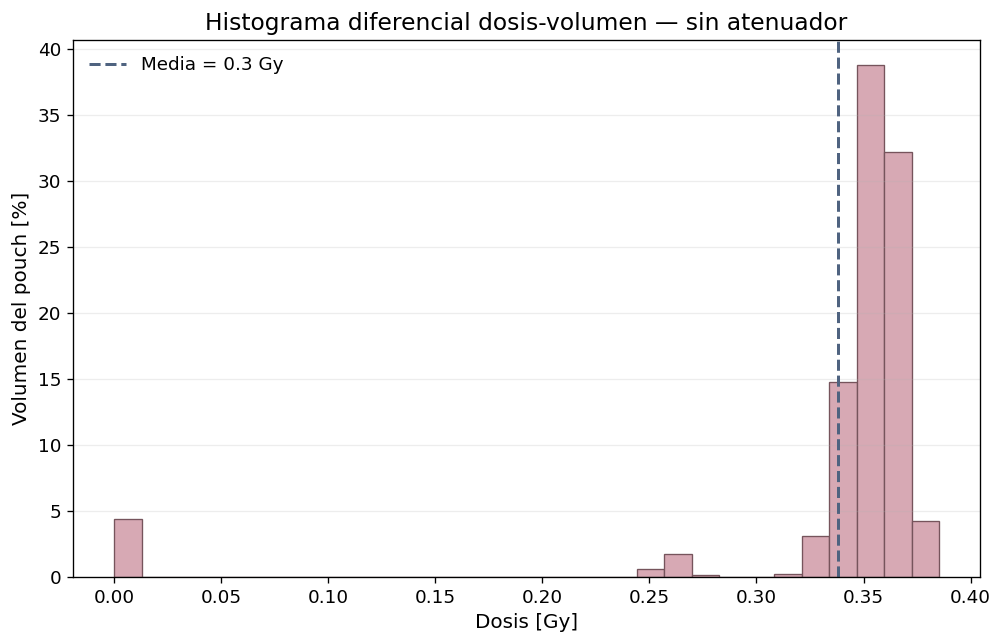

In [9]:
bins = 30
peso_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes = np.histogram(
    data_dosis,
    bins=bins,
    weights=np.full(n_voxeles, peso_voxel)
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos = np.diff(bordes)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.bar(
    centros,
    volumen_diferencial,
    width=anchos,
    align="center",
    color="#d7a9b4",
    edgecolor="#76545c",
    linewidth=0.8
)

ax.axvline(data_dosis.mean(), color="#4f6380", linestyle="--", linewidth=1.8, label=f"Media = {data_dosis.mean():.1f} Gy")

ax.set_xlabel("Dosis [Gy]")
ax.set_ylabel("Volumen del pouch [%]")
ax.set_title("Histograma diferencial dosis-volumen — sin atenuador")
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


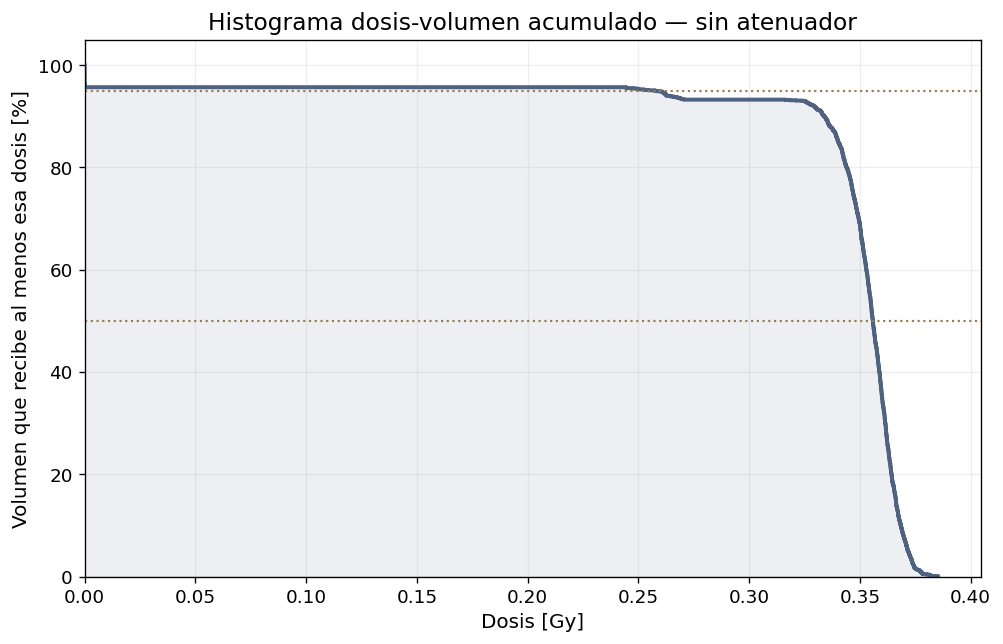

In [10]:
dosis_ordenada = np.sort(data_dosis)
volumen_acumulado = 100.0 * (n_voxeles - np.arange(n_voxeles)) / n_voxeles

dosis_grafico = np.insert(dosis_ordenada, 0, 0.0)
volumen_grafico = np.insert(volumen_acumulado, 0, 100.0)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.step(
    dosis_grafico,
    volumen_grafico,
    where="post",
    color="#4f6380",
    linewidth=2.4
)

ax.fill_between(
    dosis_grafico,
    volumen_grafico,
    step="post",
    alpha=0.10,
    color="#4f6380"
)

ax.axhline(95, color="#9a7b4f", linestyle=":", linewidth=1.3)
ax.axhline(50, color="#9a7b4f", linestyle=":", linewidth=1.3)

ax.set_xlabel("Dosis [Gy]")
ax.set_ylabel("Volumen que recibe al menos esa dosis [%]")
ax.set_title("Histograma dosis-volumen acumulado — sin atenuador")
ax.set_xlim(left=0)
ax.set_ylim(0, 105)
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()


In [11]:
def dosis_en_volumen(fraccion_volumen):
    return np.percentile(data_dosis, 100 - fraccion_volumen)

for v in [98, 95, 90, 50, 10, 5, 2]:
    print(f"D{v}: {dosis_en_volumen(v):.3f} Gy")


D98: 0.000 Gy
D95: 0.257 Gy
D90: 0.334 Gy
D50: 0.356 Gy
D10: 0.368 Gy
D5: 0.372 Gy
D2: 0.374 Gy


In [12]:
X, Y, Z = np.meshgrid(
    x_centros,
    y_centros,
    z_centros,
    indexing="ij"
)

x0 = 0.0
y0 = 0.0
z0 = 98.48

rx = 0.8
ry = 1.65
rz = 0.8

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (
    (Z >= 98.38)
    & (Z <= 98.58)
)

mascara_pouch = mascara_elipsoide & mascara_z

dosis_pouch = np.where(
    mascara_pouch,
    dosis,
    np.nan
)

err_pouch = np.where(
    mascara_pouch,
    err_rel,
    np.nan
)

print("Vóxeles totales de la malla:", dosis.size)
print("Vóxeles dentro del pouch:", np.sum(mascara_pouch))

Vóxeles totales de la malla: 2112
Vóxeles dentro del pouch: 1648


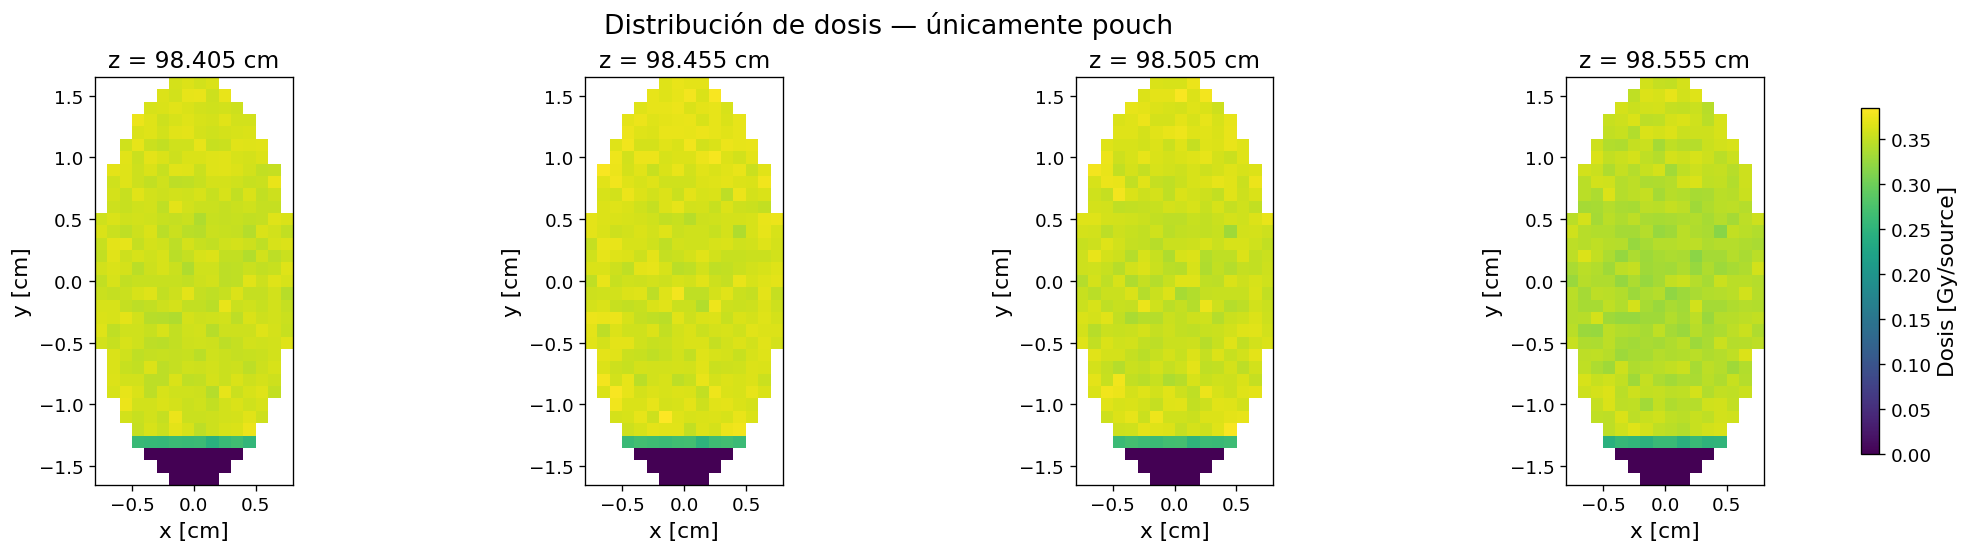

In [13]:
fig, axes = plt.subplots(
    1,
    nz,
    figsize=(4.5 * nz, 4.5),
    constrained_layout=True
)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_pouch)
vmax = np.nanmax(dosis_pouch)

for iz in range(nz):

    im = axes[iz].imshow(
        dosis_pouch[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis"
    )

    axes[iz].set_xlabel("x [cm]", fontsize=13)
    axes[iz].set_ylabel("y [cm]", fontsize=13)

    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm",
        fontsize=14
    )

    axes[iz].tick_params(labelsize=11)

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.85
)

cbar.set_label(
    "Dosis [Gy/source]",
    fontsize=13
)

plt.suptitle(
    "Distribución de dosis — únicamente pouch",
    fontsize=16
)

plt.show()

In [14]:
data_dosis_pouch = dosis_pouch[
    np.isfinite(dosis_pouch)
]

n_voxeles = len(data_dosis_pouch)

print("Cantidad de vóxeles usados:", n_voxeles)

print(
    f"Dosis mínima = {np.min(data_dosis_pouch):.5f} Gy/source"
)

print(
    f"Dosis máxima = {np.max(data_dosis_pouch):.5f} Gy/source"
)

print(
    f"Dosis media = {np.mean(data_dosis_pouch):.5f} Gy/source"
)

desvio = np.std(data_dosis_pouch)

cv = (
    desvio
    / np.mean(data_dosis_pouch)
    * 100
)

print(
    f"Desvío estándar = {desvio:.5f} Gy/source"
)

print(
    f"Coeficiente de variación = {cv:.2f} %"
)

Cantidad de vóxeles usados: 1648
Dosis mínima = 0.00000 Gy/source
Dosis máxima = 0.38533 Gy/source
Dosis media = 0.33797 Gy/source
Desvío estándar = 0.07445 Gy/source
Coeficiente de variación = 22.03 %


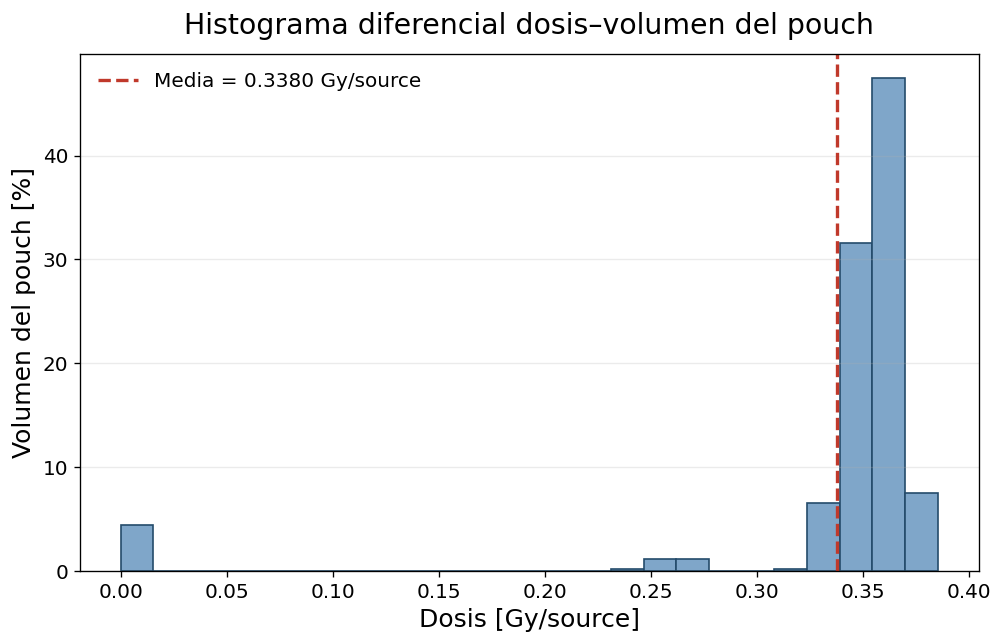

In [15]:
bins_dosis = 25

volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_pouch,
    bins=bins_dosis,
    weights=np.full(
        n_voxeles,
        volumen_por_voxel
    )
)

centros_dosis = 0.5 * (
    bordes_dosis[:-1]
    + bordes_dosis[1:]
)

anchos = np.diff(bordes_dosis)

media = np.mean(data_dosis_pouch)

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

ax.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    color="#7fa6c9",
    edgecolor="#244b6b",
    linewidth=1.0
)

ax.axvline(
    media,
    color="#c0392b",
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.4f} Gy/source"
)

ax.set_xlabel(
    "Dosis [Gy/source]",
    fontsize=15
)

ax.set_ylabel(
    "Volumen del pouch [%]",
    fontsize=15
)

ax.set_title(
    "Histograma diferencial dosis–volumen del pouch",
    fontsize=17,
    pad=12
)

ax.tick_params(
    axis="both",
    labelsize=12
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()

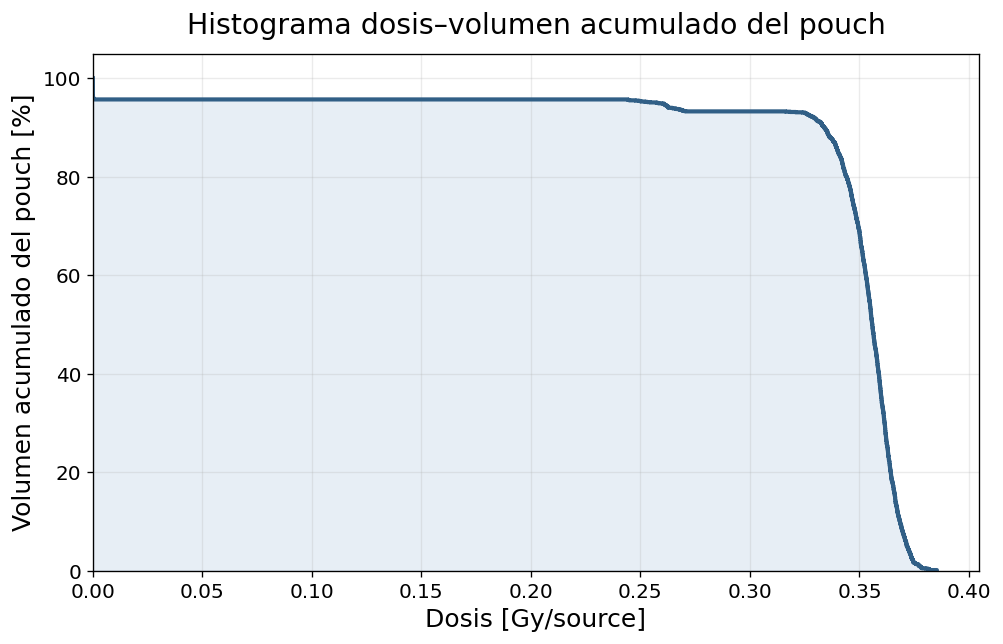

In [16]:
dosis_ordenada = np.sort(
    data_dosis_pouch
)

volumen_acumulado = (
    100.0
    * (
        1.0
        - np.arange(n_voxeles)
        / n_voxeles
    )
)

dosis_plot = np.concatenate(
    ([0.0], dosis_ordenada)
)

volumen_plot = np.concatenate(
    ([100.0], volumen_acumulado)
)

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

ax.step(
    dosis_plot,
    volumen_plot,
    where="post",
    color="#315f86",
    linewidth=2.5
)

ax.fill_between(
    dosis_plot,
    volumen_plot,
    step="post",
    color="#7fa6c9",
    alpha=0.18
)

ax.set_xlabel(
    "Dosis [Gy/source]",
    fontsize=15
)

ax.set_ylabel(
    "Volumen acumulado del pouch [%]",
    fontsize=15
)

ax.set_title(
    "Histograma dosis–volumen acumulado del pouch",
    fontsize=17,
    pad=12
)

ax.tick_params(
    axis="both",
    labelsize=12
)

ax.set_xlim(
    0,
    np.max(data_dosis_pouch) * 1.05
)

ax.set_ylim(
    0,
    105
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [17]:
dosis_pouch_sin_baja = dosis_pouch.copy()

iy_sacar = [0, 1, 2, 3]

dosis_pouch_sin_baja[:, iy_sacar, :] = np.nan

print("Vóxeles del pouch antes:", np.sum(np.isfinite(dosis_pouch)))
print("Vóxeles después de sacar las 4 filas:", np.sum(np.isfinite(dosis_pouch_sin_baja)))

Vóxeles del pouch antes: 1648
Vóxeles después de sacar las 4 filas: 1536


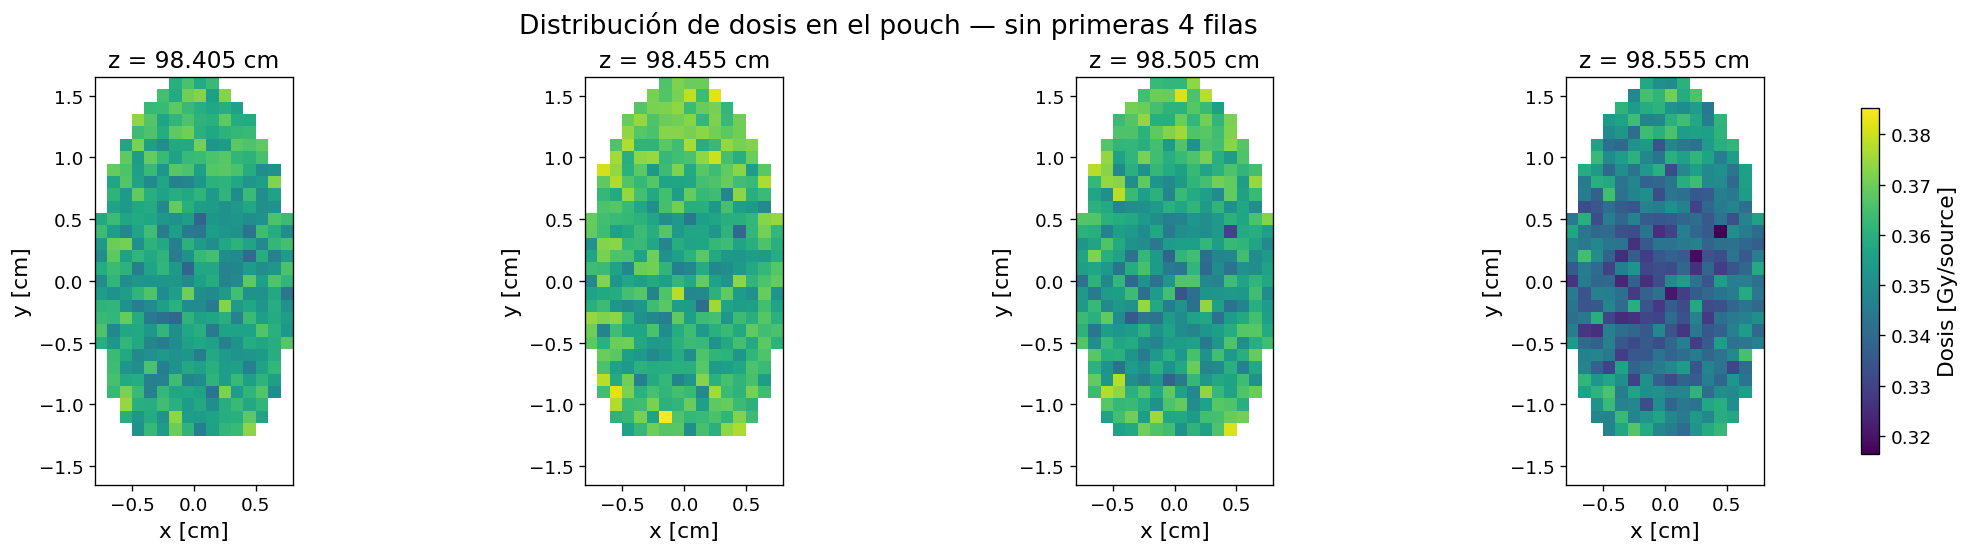

In [18]:
fig, axes = plt.subplots(
    1,
    nz,
    figsize=(4.5 * nz, 4.5),
    constrained_layout=True
)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_pouch_sin_baja)
vmax = np.nanmax(dosis_pouch_sin_baja)

for iz in range(nz):

    im = axes[iz].imshow(
        dosis_pouch_sin_baja[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis"
    )

    axes[iz].set_xlabel("x [cm]", fontsize=13)
    axes[iz].set_ylabel("y [cm]", fontsize=13)

    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm",
        fontsize=14
    )

cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Dosis [Gy/source]", fontsize=13)

plt.suptitle(
    "Distribución de dosis en el pouch — sin primeras 4 filas",
    fontsize=16
)

plt.show()

In [19]:
data_dosis_pouch = dosis_pouch_sin_baja[
    np.isfinite(dosis_pouch_sin_baja)
]

n_voxeles = len(data_dosis_pouch)

media = np.mean(data_dosis_pouch)
desvio = np.std(data_dosis_pouch)
cv = 100 * desvio / media

print(f"Vóxeles usados: {n_voxeles}")
print(f"Dosis mínima: {np.min(data_dosis_pouch):.5f} Gy/source")
print(f"Dosis máxima: {np.max(data_dosis_pouch):.5f} Gy/source")
print(f"Dosis media: {media:.5f} Gy/source")
print(f"Desvío estándar: {desvio:.5f} Gy/source")
print(f"Coeficiente de variación: {cv:.2f} %")

Vóxeles usados: 1536
Dosis mínima: 0.31637 Gy/source
Dosis máxima: 0.38533 Gy/source
Dosis media: 0.35584 Gy/source
Desvío estándar: 0.01070 Gy/source
Coeficiente de variación: 3.01 %


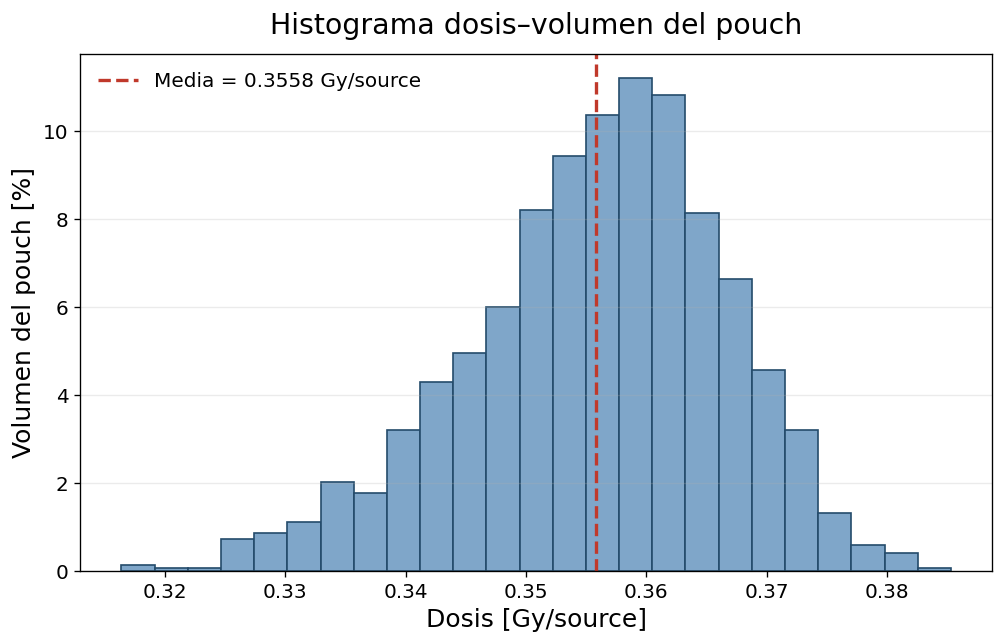

In [20]:
bins_dosis = 25

volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_pouch,
    bins=bins_dosis,
    weights=np.full(
        n_voxeles,
        volumen_por_voxel
    )
)

centros_dosis = 0.5 * (
    bordes_dosis[:-1]
    + bordes_dosis[1:]
)

anchos = np.diff(bordes_dosis)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    color="#7fa6c9",
    edgecolor="#244b6b",
    linewidth=1.0
)

ax.axvline(
    media,
    color="#c0392b",
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.4f} Gy/source"
)

ax.set_xlabel("Dosis [Gy/source]", fontsize=15)
ax.set_ylabel("Volumen del pouch [%]", fontsize=15)

ax.set_title(
    "Histograma dosis–volumen del pouch",
    fontsize=17,
    pad=12
)

ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="y", alpha=0.25)

ax.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()

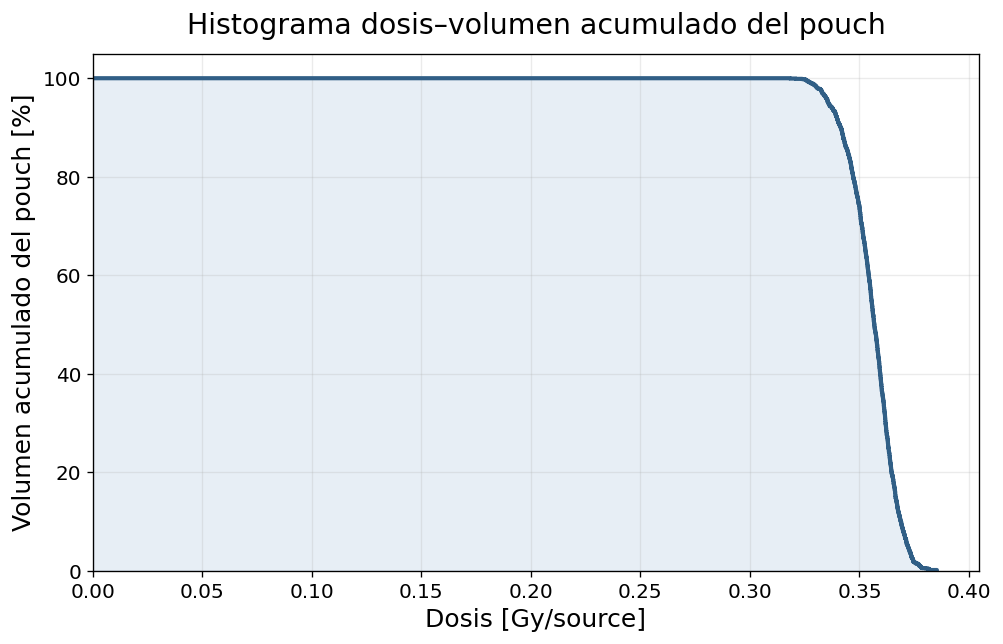

In [21]:
dosis_ordenada = np.sort(data_dosis_pouch)

volumen_acumulado = (
    100.0
    * (
        1.0
        - np.arange(n_voxeles)
        / n_voxeles
    )
)

dosis_plot = np.concatenate(
    ([0.0], dosis_ordenada)
)

volumen_plot = np.concatenate(
    ([100.0], volumen_acumulado)
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.step(
    dosis_plot,
    volumen_plot,
    where="post",
    color="#315f86",
    linewidth=2.5
)

ax.fill_between(
    dosis_plot,
    volumen_plot,
    step="post",
    color="#7fa6c9",
    alpha=0.18
)

ax.set_xlabel("Dosis [Gy/source]", fontsize=15)
ax.set_ylabel("Volumen acumulado del pouch [%]", fontsize=15)

ax.set_title(
    "Histograma dosis–volumen acumulado del pouch",
    fontsize=17,
    pad=12
)

ax.tick_params(axis="both", labelsize=12)

ax.set_xlim(
    0,
    np.max(data_dosis_pouch) * 1.05
)

ax.set_ylim(0, 105)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()